In [1]:
import os
from pathlib import Path
import glob 
from pprint import pp
from rich.progress import track

import h5py
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.signal import fftconvolve
from scipy.spatial.distance import cdist
import pymc as pm
import pytensor
import pytensor.tensor as pt
import arviz as az
from scipy.signal import lfilter
import torch
import torch.nn.functional as F
import numpy as np
from rich.progress import track
import math


/Users/gregorymunday/anaconda3/envs/cmip7/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [ ]:
def sample_members_2D(array: np.ndarray, percentiles: list|np.ndarray) -> np.ndarray:
    """Sample real ensemble members from a 2D numpy array."""
    array_percentiles = np.percentile(array, percentiles, axis=0)
    distances = cdist(array_percentiles, array)
    mem_indices = np.argmin(distances, axis=1)
    return array[mem_indices]
    
def load_global_temperature(path: str) -> np.ndarray:
    ds = xr.open_mfdataset(path).tas
    ds = ds.groupby('time.year').mean('time')
    global_weights = np.cos(np.deg2rad(ds.lat))
    ds = ds.weighted(global_weights).mean(dim=['lat', 'lon']).compute()
    tas = ds.sel(year=slice(1950, 2299))

    baseline = tas.sel(year=slice(1995, 2014)).mean()
    tas = tas.values - baseline.values
    return tas

def load_stable_temperature(path: str) -> np.ndarray:
    files = sorted(glob.glob(path))
    historical_files = [f for f in files if "historical" in f]
    ds_hist = xr.open_mfdataset(historical_files).tas
    ds_hist = ds_hist.groupby('time.year').mean('time')
    global_weights = np.cos(np.deg2rad(ds_hist.lat))
    ds_hist = ds_hist.weighted(global_weights).mean(dim=['lat', 'lon']).compute()
    
    other_files = [f for f in files if "historical" not in f]
    ds_future = xr.load_dataarray(other_files[0]) 
    ds_future = ds_future.assign_coords(year=np.arange(2015, 2300))
    ds_total = xr.concat([ds_hist, ds_future], dim='year')
    tas = ds_total.sel(year=slice(1950, 2299))
    baseline = tas.sel(year=slice(1995, 2014)).mean()
    tas = tas.values - baseline.values
    return tas

def get_model_name(path: str) -> str:
    # this needs to split at eithe _exp or _hist
    if "_exp" in path:
        return path.split("/")[-1].split("sle_goelzer_AIS_")[-1].split("_exp")[0]
    elif "_hist" in path:
        return path.split("/")[-1].split("sle_goelzer_AIS_")[-1].split("_hist")[0]
    elif "_ctrl" in path:
        return path.split("/")[-1].split("sle_goelzer_AIS_")[-1].split("_ctrl")[0]
    else:
        return path.split("/")[-1].split("sle_goelzer_AIS_")[-1]

def get_common_models(base_data_path: str) -> list[str]:
    """Uses set intersections to find models present in hist, ctrl, and ALL exps."""
    # 1. Start with models in historical
    hist_files = glob.glob(os.path.join(base_data_path, "histAE/sle_goelzer/*.nc"))
    common = set(get_model_name(f) for f in hist_files)
    
    # 2. Intersect with control models
    ctrl_files = glob.glob(os.path.join(base_data_path, "ctrlAE/sle_goelzer/*.nc"))
    common.intersection_update(get_model_name(f) for f in ctrl_files)
    
    # 3. Intersect with experiment models (only those in expAE01 to expAE10)
    exp_folders = glob.glob(os.path.join(base_data_path, "expAE[0-9][0-9]/sle_goelzer"))
    for exp in exp_folders:
        exp_files = glob.glob(os.path.join(exp, "sle_goelzer/*.nc"))
        if exp_files: # Only check valid directories containing files
            common.intersection_update(get_model_name(f) for f in exp_files)
            
    return sorted(list(common))

def load_var(exp_path: str, variable: str, common_models: list[str], subtract_control=True) -> np.ndarray:
    """Loads variables matching explicit model names to ensure correct array alignment."""
    anoms = []
    
    for model in common_models:
        hist_file = glob.glob(f"../data/AIS/histAE/sle_goelzer/*{model}*.nc")[0]
        future_file = glob.glob(f"{exp_path}/*{model}*.nc")[0]
        
        # --- 1. Load and safely pad Historical Data ---
        ds_hist = xr.open_dataset(hist_file, decode_times=False)[variable]
        ds_hist = ds_hist.assign_coords(time=ds_hist.time.astype(int))
        
        # Map to end at 2014
        start_year = 2015 - len(ds_hist.time)
        ds_hist = ds_hist.assign_coords(time=np.arange(start_year, 2015))
        
        # Reindex instead of interp. Backfill pads missing early years (e.g., 1950-1994) 
        # with the earliest available value, preventing NaNs.
        ds_hist = ds_hist.reindex(time=np.arange(1950, 2015)).bfill('time')
        
        # --- 2. Load Future Data ---
        ds_future = xr.open_dataset(future_file, decode_times=False)[variable]
        ds_future = ds_future.assign_coords(time=ds_future.time.astype(int))
        ds_future = ds_future.sel(time=slice(2015, 2299))
        
        # Combine and baseline
        ds_total = xr.concat([ds_hist, ds_future], dim="time")
        baseline = ds_total.sel(time=slice(1995, 2014)).mean()
        ds_total -= baseline
        
        # --- 3. Safely handle Control Data ---
        if subtract_control:
            ctrl_file = glob.glob(f"../data/AIS/ctrlAE/sle_goelzer/*{model}*.nc")[0]
            ctrl_ds = xr.open_dataset(ctrl_file, decode_times=False)[variable]
            ctrl_ds = ctrl_ds.assign_coords(time=ctrl_ds.time.astype(int))
            
            # Reindex control to match the EXACT 1950-2299 timeline.
            # Forward/Backward fill ensures if control only runs 2015-2100, 
            # it pads safely rather than dropping coordinates.
            ctrl_ds = ctrl_ds.reindex(time=np.arange(1950, 2300)).bfill('time').ffill('time')
            
            ctrl_baseline = ctrl_ds.sel(time=slice(1995, 2014)).mean()
            ctrl_ds -= ctrl_baseline
            
            # Now coordinate lengths match exactly; no NaNs are injected.
            ds_total -= ctrl_ds

        anoms.append(ds_total.values)
        
    return np.array(anoms)

# But I only want to find common models between ctrl, hist, and exps "01" to "10", not just all exps
base_data_path = "../data/AIS"
common_models = get_common_models(base_data_path)
print("number of common models:", len(common_models))

# # High emissions temperatures
ccsm4_tas_85 = load_global_temperature('../data/AIS/forcing/global/CCSM4/*.nc')
cesm2_tas_585 = load_global_temperature('../data/AIS/forcing/global/CESM2-WACCM/*.nc')
ukesm_tas_585 = load_global_temperature('../data/AIS/forcing/global/UKESM1-0-LL/*.nc')
hadgem2_tas_85 = load_global_temperature('../data/AIS/forcing/global/HadGEM2-ES/*.nc')

# Stabilisation temperatures
ukesm_stable_tas_585 = load_stable_temperature('../data/AIS/forcing/global/UKESM1-0-LL_STABLE/*.nc')
cesm2_stable_tas_585 = load_stable_temperature('../data/AIS/forcing/global/CESM2-WACCM_STABLE/*.nc')
hadgem2_stable_tas_85 = load_stable_temperature('../data/AIS/forcing/global/HadGEM2-ES_STABLE/*.nc')
noresm_stable_tas_85 = load_stable_temperature('../data/AIS/forcing/global/NorESM1-M_STABLE_85/*.nc')

# Low emissions temperatures
ukesm_tas_26 = load_global_temperature('../data/AIS/forcing/global/UKESM1-0-LL_126/*.nc')
noresm_tas_26 = load_stable_temperature('../data/AIS/forcing/global/NorESM1-M_STABLE_26/*.nc')

# SLE (Passing common_models and the specific experiment directory path)
region = 1
noresm_sle_26 = load_var('../data/AIS/expAE01/sle_goelzer', f'sle_goelzer_region_{region}', common_models)
ccsm4_sle_85 = load_var('../data/AIS/expAE02/sle_goelzer', f'sle_goelzer_region_{region}', common_models)
hadgem2_sle_85 = load_var('../data/AIS/expAE03/sle_goelzer', f'sle_goelzer_region_{region}', common_models)
cesm2_sle_585 = load_var('../data/AIS/expAE04/sle_goelzer', f'sle_goelzer_region_{region}', common_models)
ukesm_sle_585 = load_var('../data/AIS/expAE05/sle_goelzer', f'sle_goelzer_region_{region}', common_models)
ukesm_stable_sle_585 = load_var('../data/AIS/expAE06/sle_goelzer', f'sle_goelzer_region_{region}', common_models)
noresm_stable_sle_85 = load_var('../data/AIS/expAE07/sle_goelzer', f'sle_goelzer_region_{region}', common_models)
hadgem2_stable_sle_85 = load_var('../data/AIS/expAE08/sle_goelzer', f'sle_goelzer_region_{region}', common_models)
cesm2_stable_sle_585 = load_var('../data/AIS/expAE09/sle_goelzer', f'sle_goelzer_region_{region}', common_models)
ukesm_sle_26 = load_var('../data/AIS/expAE10/sle_goelzer', f'sle_goelzer_region_{region}', common_models)

In [2]:
def sample_members_2D(array: np.ndarray, percentiles: list|np.ndarray) -> np.ndarray:
    """Sample real ensemble members from a 2D numpy array."""
    # Caculate statistical timeseries, then match with closest real timeseries 
    array_percentiles = np.percentile(array, percentiles, axis=0)
    distances = cdist(array_percentiles, array)
    mem_indices = np.argmin(distances, axis=1)
    return array[mem_indices]
    
def load_global_temperature(path: str) -> np.ndarray:
    ds = xr.open_mfdataset(path).tas
    ds = ds.groupby('time.year').mean('time')
    global_weights = np.cos(np.deg2rad(ds.lat))
    ds = ds.weighted(global_weights).mean(dim=['lat', 'lon']).compute()
    tas = ds.sel(year=slice(1950, 2299))

    baseline = tas.sel(year=slice(1995, 2014)).mean()
    # Now cut to 2015-2299 to match the SLE data, and baseline to 1995-2014
    tas.values -= baseline.values
    tas = tas.sel(year=slice(2015, 2299)).values
    return tas

# def load_stable_temperature(path: str) -> np.ndarray:
#     files = sorted(glob.glob(path))
#     historical_files = [f for f in files if "historical" in f]
#     ds_hist = xr.open_mfdataset(historical_files).tas
#     ds_hist = ds_hist.groupby('time.year').mean('time')
#     global_weights = np.cos(np.deg2rad(ds_hist.lat))
#     ds_hist = ds_hist.weighted(global_weights).mean(dim=['lat', 'lon']).compute()
    
#     other_files = [f for f in files if "historical" not in f]
#     ds_future = xr.load_dataarray(other_files[0]) 
#     ds_future = ds_future.assign_coords(year=np.arange(2015, 2300))
#     ds_total = xr.concat([ds_hist, ds_future], dim='year')
#     tas = ds_total.sel(year=slice(1950, 2299))
#     baseline = tas.sel(year=slice(1995, 2014)).mean()
#     tas = tas.values - baseline.values
#     return tas

def load_stable_temperature(path: str) -> np.ndarray:
    files = sorted(glob.glob(path))
    historical_files = [f for f in files if "historical" in f]
    ds_hist = xr.open_mfdataset(historical_files).tas
    ds_hist = ds_hist.groupby('time.year').mean('time')
    global_weights = np.cos(np.deg2rad(ds_hist.lat))
    ds_hist = ds_hist.weighted(global_weights).mean(dim=['lat', 'lon']).compute()

    strange_flag = False
    if ds_hist.mean() > 100:
        ds_hist -= 273.15
        ds_hist -= ds_hist[-1]
        strange_flag = True
    
    other_files = [f for f in files if "historical" not in f]
    ds_future = xr.load_dataarray(other_files[0]) 
    ds_future = ds_future.assign_coords(year=np.arange(2015, 2300))
    if strange_flag:
        ds_future = ds_future.assign_coords(year=np.arange(2015, 2300))
        # Add 9 years onto the historical (2006-2014 inclusive) and interpolate

    ds_total = xr.concat([ds_hist, ds_future], dim='year')
    tas = ds_total.sel(year=slice(1950, 2299))
    # Interpolate over missions years
    baseline = tas.sel(year=slice(1995, 2014)).mean()
    tas.values -= baseline.values
    tas = tas.sel(year=slice(2015, 2299)).values
    return tas


def get_model_name(path: str) -> str:
    # this needs to split at eithe _exp or _hist
    if "_exp" in path:
        return path.split("/")[-1].split("sle_goelzer_AIS_")[-1].split("_exp")[0]
    elif "_hist" in path:
        return path.split("/")[-1].split("sle_goelzer_AIS_")[-1].split("_hist")[0]
    elif "_ctrl" in path:
        return path.split("/")[-1].split("sle_goelzer_AIS_")[-1].split("_ctrl")[0]
    else:
        return path.split("/")[-1].split("sle_goelzer_AIS_")[-1]


def load_var(exp_path: str, variable: str, common_models: list[str], subtract_control=True) -> np.ndarray:
    """Loads variables matching explicit model names for 2015-2300, subtracting control drift."""
    anoms = []
    
    for model in common_models:
        print(f"Processing: {model}")
        future_file = glob.glob(f"{exp_path}/*{model}*.nc")[0]
        
        # --- 1. Load Future Data ---
        ds_exp = xr.open_dataset(future_file, decode_times=False)[variable]
        
        # Explicitly define timeline assuming start year is 2015
        ds_exp = ds_exp.assign_coords(time=np.arange(2015, 2015 + len(ds_exp.time)))
        ds_exp = ds_exp.sel(time=slice(2015, 2299))
        
        # Baseline: Set SLE(2015) = 0
        ds_exp -= ds_exp.isel(time=0)
        
        # --- 2. Handle Control Data ---
        if subtract_control:
            ctrl_file = glob.glob(f"../data/AIS/ctrlAE/sle_goelzer/*{model}*.nc")[0]
            ctrl_ds = xr.open_dataset(ctrl_file, decode_times=False)[variable]
            
            # Align control to 2015
            ctrl_ds = ctrl_ds.assign_coords(time=np.arange(2015, 2015 + len(ctrl_ds.time)))
            
            # Reindex to force 2015-2299 timeline. Forward fill if control run is shorter than 285 years.
            ctrl_ds = ctrl_ds.reindex(time=np.arange(2015, 2300)).ffill('time')
            
            # Baseline control to its own 2015 state to isolate future drift
            ctrl_ds -= ctrl_ds.isel(time=0)
            
            # Subtract drift
            ds_exp -= ctrl_ds

        anoms.append(ds_exp.values)
        
    return np.array(anoms)

def load_common_models(path: str, variable: str, common_models: list[str]):
    files = sorted(glob.glob(path))
    common_files = []
    for file in files:
        for model in common_models:
            if model in file:
                common_files.append(file)
    common_files = list(set(common_files))
    anoms = []
    for f in common_files:
        ds = xr.open_dataset(f, decode_times=False)[f'{variable}']
        ds = ds.sel(time=slice(2015, 2299)).values
        if variable == variable:
            ds -= ds[0]
        anoms.append(ds)
    return np.array(anoms)

def get_common_models(base_data_path: str) -> list[str]:
    """Uses set intersections to find models present in hist, ctrl, and exps 01-10."""
    
    # 1. Start with models in historical
    hist_files = glob.glob(os.path.join(base_data_path, "histAE/sle_goelzer/*.nc"))
    common = set(get_model_name(f) for f in hist_files)
    
    if not common:
        return [] 
    
    # 2. Intersect with control models
    ctrl_files = glob.glob(os.path.join(base_data_path, "ctrlAE/sle_goelzer/*.nc"))
    common.intersection_update(get_model_name(f) for f in ctrl_files)
    
    # 3. Intersect explicitly with experiments 01 through 10
    # Generate the exact folder paths (e.g., expAE01, expAE02... expAE10)
    exp_folders = [os.path.join(base_data_path, f"expAE{i:02d}") for i in range(1, 7)]
    
    for exp in exp_folders:
        # We still use glob here to grab the actual .nc files inside the target folder
        exp_files = glob.glob(os.path.join(exp, "sle_goelzer/*.nc"))
        
        common.intersection_update(get_model_name(f) for f in exp_files)
        
        if not common:
            break
            
    return sorted(list(common))

base_data_path = "../data/AIS"
common_models = get_common_models(base_data_path)
print("number of common models:", len(common_models))

# High emissions temperatures
ccsm4_tas_85 = load_global_temperature('../data/AIS/forcing/global/CCSM4/*.nc')
cesm2_tas_585 = load_global_temperature('../data/AIS/forcing/global/CESM2-WACCM/*.nc')
ukesm_tas_585 = load_global_temperature('../data/AIS/forcing/global/UKESM1-0-LL/*.nc')
hadgem2_tas_85 = load_global_temperature('../data/AIS/forcing/global/HadGEM2-ES/*.nc')

# Stabilisation temperatures
ukesm_stable_tas_585 = load_stable_temperature('../data/AIS/forcing/global/UKESM1-0-LL_STABLE/*.nc')
# cesm2_stable_tas_585 = load_stable_temperature('../data/AIS/forcing/global/CESM2-WACCM_STABLE/*.nc')
# hadgem2_stable_tas_85 = load_stable_temperature('../data/AIS/forcing/global/HadGEM2-ES_STABLE/*.nc')
# noresm_stable_tas_85 = load_stable_temperature('../data/AIS/forcing/global/NorESM1-M_STABLE_85/*.nc')

# Low emissions temperatures
# ukesm_tas_26 = load_global_temperature('../data/AIS/forcing/global/UKESM1-0-LL_126/*.nc')
noresm_tas_26 = load_stable_temperature('../data/AIS/forcing/global/NorESM1-M_STABLE_26/*.nc')

# model_list = sorted(glob.glob('../data/AIS/expAE04/sle_goelzer/*.nc'))
# model_names = [item.split("/")[-1].split("sle_AIS_")[-1].split("_exp")[0] for item in model_list]
# common_models = get_common_models("../data/AIS/", "sle", model_names.copy())

# # SLE
region = 2
noresm_sle_26 = load_var('../data/AIS/expAE01/sle_goelzer', f'sle_goelzer_region_{region}', common_models)
ccsm4_sle_85 = load_var('../data/AIS/expAE02/sle_goelzer', f'sle_goelzer_region_{region}', common_models)
hadgem2_sle_85 = load_var('../data/AIS/expAE03/sle_goelzer', f'sle_goelzer_region_{region}', common_models)
cesm2_sle_585 = load_var('../data/AIS/expAE04/sle_goelzer', f'sle_goelzer_region_{region}', common_models)
ukesm_sle_585 = load_var('../data/AIS/expAE05/sle_goelzer', f'sle_goelzer_region_{region}', common_models)
ukesm_stable_sle_585 = load_var('../data/AIS/expAE06/sle_goelzer', f'sle_goelzer_region_{region}', common_models)
# noresm_stable_sle_85 = load_var('../data/AIS/expAE07/sle_goelzer', f'sle_goelzer_region_{region}', common_models)
# hadgem2_stable_sle_85 = load_var('../data/AIS/expAE08/sle_goelzer', f'sle_goelzer_region_{region}', common_models)
# cesm2_stable_sle_585 = load_var('../data/AIS/expAE09/sle_goelzer', f'sle_goelzer_region_{region}', common_models)
# ukesm_sle_26 = load_var('../data/AIS/expAE10/sle_goelzer', f'sle_goelzer_region_{region}', common_models)

# c_noresm_sle_26 = load_common_models('../data/AIS/expAE01/sle/*.nc', 'sle', common_models)
# c_ccsm4_sle_85 = load_common_models('../data/AIS/expAE02/sle/*.nc', 'sle', common_models)
# c_hadgem2_sle_85 = load_common_models('../data/AIS/expAE03/sle/*.nc', 'sle', common_models)
# c_cesm2_sle_585 = load_common_models('../data/AIS/expAE04/sle/*.nc', 'sle', common_models)
# c_ukesm_sle_585 = load_common_models('../data/AIS/expAE05/sle/*.nc', 'sle', common_models)
# c_ukesm_stable_sle_585 = load_common_models('../data/AIS/expAE06/sle/*.nc', 'sle', common_models)
# c_noresm_stable_sle_85 = load_common_models('../data/AIS/expAE07/sle/*.nc', 'sle', common_models)
# c_hadgem2_stable_sle_85 = load_common_models('../data/AIS/expAE08/sle/*.nc', 'sle', common_models)
# c_cesm2_stable_sle_585 = load_common_models('../data/AIS/expAE09/sle/*.nc', 'sle', common_models)
# c_ukesm_sle_26 = load_common_models('../data/AIS/expAE10/sle/*.nc', 'sle', common_models)
# c_ukesm_tas_585 = load_common_models("../data/AIS/expAE05/sle/*.nc", "sle", common_models)

number of common models: 32


/var/folders/sb/qqz4tyy142q_jb2y2lj_1x580000gn/T/ipykernel_53959/1180984437.py:10: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds = xr.open_mfdataset(path).tas
/var/folders/sb/qqz4tyy142q_jb2y2lj_1x580000gn/T/ipykernel_53959/1180984437.py:10: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'lat' ('lat',) The recommendation is to set join explicitly for this case.
  ds = xr.open_mfdataset(path).tas
/var/folders/sb/qqz4tyy142q_jb2y2lj_1x580000gn/T/ipykernel_53959/1180984437.py:10: FutureWarning: In a future version of xarray the default valu

Processing: DOE_MALI_4km
Processing: DOE_MALI_8km_Ant95
Processing: DOE_MALI_8km_AntMean
Processing: IGE_ElmerIce
Processing: ILTS_SICOPOLIS
Processing: IMAU_UFEMISM1
Processing: IMAU_UFEMISM2
Processing: IMAU_UFEMISM3
Processing: IMAU_UFEMISM4
Processing: LSCE_GRISLI
Processing: LSCE_GRISLI2
Processing: NCAR_CISM1
Processing: NORCE_CISM2-MAR364-ERA-t1
Processing: NORCE_CISM3-MAR364-ERA-t1
Processing: NORCE_CISM3-MAR364-ERA-t1-local
Processing: NORCE_CISM3-MAR364-ERA-t1-nonlocal
Processing: NORCE_CISM4-MAR364-ERA-t1
Processing: NORCE_CISM4-MAR364-ERA-t1-local
Processing: NORCE_CISM4-MAR364-ERA-t1-nonlocal
Processing: NORCE_CISM4-MAR364-JRA-t1
Processing: NORCE_CISM5-MAR364-ERA-t1
Processing: NORCE_CISM5-MAR364-ERA-t1-local
Processing: NORCE_CISM5-MAR364-ERA-t1-nonlocal
Processing: PIK_PISM
Processing: UCM_Yelmo
Processing: UCSD_ISSM
Processing: ULB_fETISh-KoriBU1
Processing: ULB_fETISh-KoriBU2
Processing: UNN_Ua
Processing: UTAS_ElmerIce
Processing: VUB_AISMPALEO
Processing: VUW_PISM1


In [3]:
# Training data
# tas_train = np.array([
#     cesm2_tas_585, # high
#     ccsm4_tas_85, # high
#     hadgem2_tas_85, # high
#     ukesm_tas_585, # high ])
#     noresm_tas_26,
#     ukesm_stable_tas_585
#     ]) # stable
# sle_train = np.array([
#     cesm2_sle_585,
#     ccsm4_sle_85,
#     hadgem2_sle_85, 
#     ukesm_sle_585,
#     noresm_sle_26,
#     ukesm_stable_sle_585
#     ])[:, :, :]
# t_int_train = np.array([
#     np.cumsum(cesm2_tas_585), 
#     np.cumsum(ccsm4_tas_85), 
#     np.cumsum(hadgem2_tas_85),
#     np.cumsum(ukesm_tas_585),
#     np.cumsum(noresm_tas_26),
#     np.cumsum(ukesm_stable_tas_585)
#     ])

# # Test data
# tas_test = np.array([
#     noresm_stable_tas_85, # stable
#     hadgem2_stable_tas_85, # stable
#     cesm2_stable_tas_585, # stable
#     ukesm_tas_26]) # low

# t_int_test = np.array([
#     np.cumsum(noresm_stable_tas_85), 
#     np.cumsum(hadgem2_stable_tas_85), 
#     np.cumsum(cesm2_stable_tas_585), 
#     np.cumsum(ukesm_tas_26)])
# sle_test = [
#     noresm_stable_sle_85,
#     hadgem2_stable_sle_85,
#     cesm2_stable_sle_585,
#     ukesm_sle_26]


# # # Try to train with all data
# # Training data
tas_train = np.array([
    cesm2_tas_585, # high
    ccsm4_tas_85, # high
    hadgem2_tas_85, # high
    ukesm_tas_585, # high ])
    noresm_tas_26,
    ukesm_stable_tas_585,
    # noresm_stable_tas_85, # stable
    # hadgem2_stable_tas_85, # stable
    # cesm2_stable_tas_585, # stable
    # ukesm_tas_26
    ])# stable
sle_train = np.array([
    cesm2_sle_585,
    ccsm4_sle_85,
    hadgem2_sle_85, 
    ukesm_sle_585,
    noresm_sle_26,
    ukesm_stable_sle_585,
    # noresm_stable_sle_85,
    # hadgem2_stable_sle_85,
    # cesm2_stable_sle_585,
    # ukesm_sle_26
    ])
t_int_train = [
    np.cumsum(cesm2_tas_585), 
    np.cumsum(ccsm4_tas_85), 
    np.cumsum(hadgem2_tas_85),
    np.cumsum(ukesm_tas_585),
    np.cumsum(noresm_tas_26),
    np.cumsum(ukesm_stable_tas_585),
    # np.cumsum(noresm_stable_tas_85), 
    # np.cumsum(hadgem2_stable_tas_85), 
    # np.cumsum(cesm2_stable_tas_585), 
    # np.cumsum(ukesm_tas_26)
]

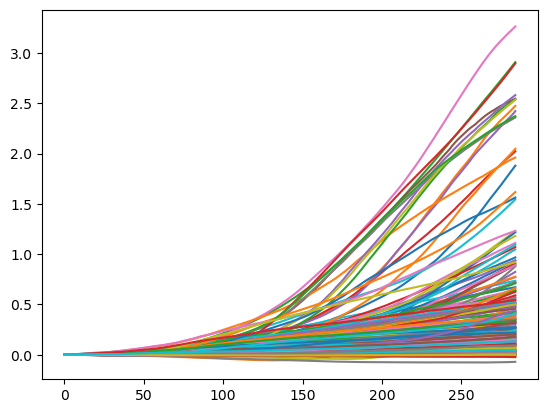

In [161]:
for i in range(len(sle_train)):
    plt.plot(sle_train[i].T)

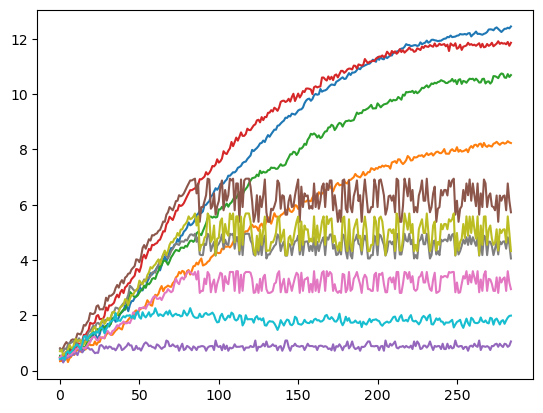

In [162]:
for i in range(len(tas_train)):
    plt.plot(tas_train[i], label=f"tas {i}")

In [4]:
# --- 0. Normalizer Helper ---
class DataNormalizer:
    def __init__(self):
        self.scale_tas = 1.0
        self.scale_tint = 1.0
        self.scale_y = 1.0
        
    def fit(self, tas_flat, t_int_flat, y_flat):
        # Scale by Max Absolute Value to preserve Zero and Sign
        self.scale_tas = np.max(np.abs(tas_flat)) if np.max(np.abs(tas_flat)) > 0 else 1.0
        self.scale_tint = np.max(np.abs(t_int_flat)) if np.max(np.abs(t_int_flat)) > 0 else 1.0
        self.scale_y = np.max(np.abs(y_flat)) if np.max(np.abs(y_flat)) > 0 else 1.0
        
    def transform_X(self, tas, t_int):
        return tas / self.scale_tas, t_int / self.scale_tint

    def transform_y(self, y):
        return y / self.scale_y

# # --- 1. Define New Model Functions (The Split Logic) ---

# def predict_split_model(tas, t_int, params, tau, gamma, dt=1):
#     """
#     CORRECTED PHYSICS MODEL:
#     Both SMB and Dynamics drive the RATE of sea level rise.
#     SLE = Integral( SMB_Rate + Dynamic_Rate )
    
#     1. Fast Rate: beta * T
#     2. Slow Rate: Convolve(alpha * |T|^gamma, tau)
#     """
#     alpha, beta = params
#     n = len(tas)
    
#     # Fast Term: Rate is beta*T, so Cumulative is beta * Integral(T)
#     term_fast_cumulative = beta * t_int
    
#     # Slow Term: Rate is Lagged(T^gamma)
#     forcing_rate = alpha * np.sign(tas) * (np.abs(tas) ** gamma)

#     decay_factors = np.exp(-np.arange(n) * dt / tau) * (dt / tau)
#     dynamic_rate_delayed = fftconvolve(forcing_rate, decay_factors, mode="full", axes=-1)[:n]
    
#     # Integrate Rate to get Cumulative
#     term_slow_cumulative = np.cumsum(dynamic_rate_delayed) * dt
    
#     return term_fast_cumulative + term_slow_cumulative

# def residuals_fixed_tau(params_no_tau, tau_fixed, gamma_fixed, tas_flat, t_int_flat, y_flat, splits):
#     alpha, beta = params_no_tau
#     all_res = []
#     start_idx = 0
#     for end_idx in splits:
#         tas_s = tas_flat[start_idx:end_idx]
#         t_int_s = t_int_flat[start_idx:end_idx]
#         y_s = y_flat[start_idx:end_idx]
#         y_pred = predict_split_model(tas_s, t_int_s, [alpha, beta], tau_fixed, gamma_fixed)
#         all_res.append(y_pred - y_s)
#         start_idx = end_idx
#     return np.concatenate(all_res)

# def residuals_specific_regularized(params_abc, tau_fixed, gamma_fixed, tas, t_int, y_obs, 
#                                    general_abc, lambda_reg):
#     y_pred = predict_split_model(tas, t_int, params_abc, tau_fixed, gamma_fixed)
#     phys_res = y_pred - y_obs
#     reg_res = np.sqrt(lambda_reg) * (params_abc - general_abc)
#     return np.concatenate([phys_res, reg_res])

# # --- 2. Predict Ensemble (Must match new physics) ---

# def predict_split_ensemble(X, general_params, general_taus, general_gammas, mv_dists):
#     tas, t_int = X
#     n_models = len(general_params)
#     n_samples = mv_dists[0].shape[0]
#     n_time = len(tas)
    
#     all_preds = np.zeros((n_models, n_samples, n_time))
    
#     for m in track(range(n_models), description="Projecting..."):
#         tau = general_timescales[m]
#         gamma = general_gammas[m]
#         gen_p = general_params[m]
#         perturb_p = mv_dists[m]
        
#         total_params = gen_p + perturb_p
#         alphas = total_params[:, 0]
#         betas = total_params[:, 1]
        
#         term_fast = betas[:, None] * t_int[None, :]
        
#         decay_factors = np.exp(-np.arange(n_time) * 1 / tau) * (1 / tau)
#         forcing_base = np.sign(tas) * (np.abs(tas) ** gamma)
#         rate_delayed = fftconvolve(forcing_base, decay_factors, mode="full", axes=-1)[:n_time]
#         term_slow_cumulative = np.cumsum(rate_delayed, axis=0) # Cumsum over time
        
#         # Scale by Alpha
#         term_slow = alphas[:, None] * term_slow_cumulative[None, :]
        
#         all_preds[m, :, :] = term_fast + term_slow
            
#     return all_preds

# def calc_mv_dists(general_params, param_residuals, n_samples):
#     mv_dists = []
#     covariances = []
#     n_params = general_params.shape[1] 
    
#     for m in range(len(general_params)):
#         cov = np.cov(param_residuals[m].T)
#         cov += np.eye(n_params) * 1e-8 
#         covariances.append(cov)
#         try:
#             samples = np.random.multivariate_normal(np.zeros(n_params), cov, size=n_samples)
#         except:
#             samples = np.random.normal(0, 1e-6, size=(n_samples, n_params))
#         mv_dists.append(samples)
#     return mv_dists, np.array(covariances)

In [5]:
# --- 1. Differentiable FFT Convolution ---
def torch_fftconvolve_1d(x, h):
    n = x.size(-1) + h.size(-1) - 1
    N = 2 ** (math.ceil(math.log2(n))) 
    X = torch.fft.rfft(x, n=N)
    H = torch.fft.rfft(h, n=N)
    ret = torch.fft.irfft(X * H, n=N)
    return ret[:n]

# --- 2. Differentiable Dual-Timescale Solver ---
def compute_loss_and_coeffs_dual_stabilized(tau1, tau2, gamma, tas_flat, t_int_flat, y_flat, splits, lambda_l2=1e-4, dt=1.0):
    col_slow1 = []
    col_slow2 = []
    col_fast = [] 
    
    start_idx = 0
    split_diffs = [splits[0]] + [splits[i] - splits[i-1] for i in range(1, len(splits))]
    max_len = int(max(split_diffs))
    
    # Build dual decay factors
    t_arr = torch.arange(max_len, device=tau1.device, dtype=tau1.dtype)
    # decay_factors1 = torch.exp(-t_arr * dt / tau1) * (dt / tau1)
    # decay_factors2 = torch.exp(-t_arr * dt / tau2) * (dt / tau2)
    decay_factors1 = (t_arr * dt / tau1**2) * torch.exp(-t_arr * dt / tau1) * dt
    decay_factors2 = (t_arr * dt / tau2**2) * torch.exp(-t_arr * dt / tau2) * dt
    
    for end_idx in splits:
        tas_s = tas_flat[start_idx:end_idx]
        t_int_s = t_int_flat[start_idx:end_idx]
        current_len = len(tas_s)
        
        # Fast Term
        col_fast.append(t_int_s)
        
        # Slow Terms (Dual routing)
        forcing_rate = torch.sign(tas_s) * (torch.abs(tas_s) ** gamma)
        
        rate_delayed1 = torch_fftconvolve_1d(forcing_rate, decay_factors1[:current_len])[:current_len]
        col_slow1.append(torch.cumsum(rate_delayed1, dim=0) * dt)
        
        rate_delayed2 = torch_fftconvolve_1d(forcing_rate, decay_factors2[:current_len])[:current_len]
        col_slow2.append(torch.cumsum(rate_delayed2, dim=0) * dt)
        
        start_idx = end_idx
        
    # Stack columns: Shape (N_total, 4)
    X_mat = torch.stack([
        torch.cat(col_slow1), 
        torch.cat(col_slow2), 
        torch.cat(col_fast),
    ], dim=1)
    
    y_target = y_flat.unsqueeze(1)
    
    # --- TIKHONOV STABILIZATION FOR INNER SOLVER ---
    # # Augment X and y to enforce L2 regularization directly in the lstsq solver
    # n_features = X_mat.size(1)
    # X_reg = torch.eye(n_features, device=tau1.device, dtype=tau1.dtype) * math.sqrt(lambda_l2)
    # y_reg = torch.zeros((n_features, 1), device=tau1.device, dtype=tau1.dtype)
    
    # X_aug = torch.cat([X_mat, X_reg], dim=0)
    # y_aug = torch.cat([y_target, y_reg], dim=0)
    
    # # LSTSQ Solve on well-conditioned augmented matrix
    # coeffs = torch.linalg.lstsq(X_aug, y_aug).solution
    # --- MODIFIED TIKHONOV STABILIZATION ---
    n_features = X_mat.size(1)
    
    # Create a base penalty vector: [alpha1, alpha2, beta, drift]
    # We penalize beta (index 2) heavily to suppress the fast response
    fast_penalty_factor = 100.0
    penalty_weights = torch.tensor([1.0, 1.0, fast_penalty_factor], 
                                   device=tau1.device, dtype=tau1.dtype)
    
    # Apply weights to the diagonal matrix
    X_reg = torch.diag(penalty_weights) * math.sqrt(lambda_l2)
    y_reg = torch.zeros((n_features, 1), device=tau1.device, dtype=tau1.dtype)
    
    X_aug = torch.cat([X_mat, X_reg], dim=0)
    y_aug = torch.cat([y_target, y_reg], dim=0)
    
    # LSTSQ Solve
    coeffs = torch.linalg.lstsq(X_aug, y_aug).solution
    
    # Calculate pure MSE cost on original (unaugmented) predictions
    predictions = X_mat @ coeffs
    cost = torch.sum((y_target - predictions)**2)
    
    return cost, coeffs.squeeze(), predictions

# --- 3. Specific Ridge Solver (4-Parameter) ---
def torch_solve_specific_ridge_dual(tau1, tau2, gamma, tas_s, t_int_s, y_s, global_params, lambda_reg, dt=1.0):
    n_samples = len(tas_s)
    
    t_arr = torch.arange(n_samples, device=tau1.device, dtype=tau1.dtype)
    # decay_factors1 = torch.exp(-t_arr * dt / tau1) * (dt / tau1)
    # decay_factors2 = torch.exp(-t_arr * dt / tau2) * (dt / tau2)
    decay_factors1 = (t_arr * dt / tau1**2) * torch.exp(-t_arr * dt / tau1) * dt
    decay_factors2 = (t_arr * dt / tau2**2) * torch.exp(-t_arr * dt / tau2) * dt
    
    forcing_rate = torch.sign(tas_s) * (torch.abs(tas_s) ** gamma)
    
    rate_delayed1 = torch_fftconvolve_1d(forcing_rate, decay_factors1)[:n_samples]
    col_slow1 = torch.cumsum(rate_delayed1, dim=0) * dt
    
    rate_delayed2 = torch_fftconvolve_1d(forcing_rate, decay_factors2)[:n_samples]
    col_slow2 = torch.cumsum(rate_delayed2, dim=0) * dt
    
    col_fast = t_int_s
    
    X_phys = torch.stack([col_slow1, col_slow2, col_fast], dim=1)
    
    # 4x4 Regularization
    X_reg = torch.eye(3, device=tau1.device, dtype=tau1.dtype) * math.sqrt(lambda_reg)
    y_reg = global_params * math.sqrt(lambda_reg)
    
    X_total = torch.cat([X_phys, X_reg], dim=0)
    y_total = torch.cat([y_s, y_reg], dim=0)
    
    coeffs = torch.linalg.lstsq(X_total, y_total.unsqueeze(1)).solution
    return coeffs.squeeze()

# --- 4. Main Training Loop ---

general_params = [] 
general_timescales = [] # Now stores tuples of (tau1, tau2)
general_gammas = []
specific_params = [] 

lambda_reg = 1e6
device = torch.device("cpu")

n_iterations = 600
learning_rate = 0.1
dtype = torch.float64

# Multi-Start: Exploring fast vs slow combinations
initial_guesses = [
    {'tau1': 10.0, 'tau2': 100.0, 'gamma': 1.0},   # Your baseline
    # {'tau1': 50.0, 'tau2': 300.0, 'gamma': 1.0},   # Moderate inertia
    # {'tau1': 150.0, 'tau2': 800.0, 'gamma': 1.0},  # Extreme long-term memory
    # {'tau1': 30.0, 'tau2': 500.0, 'gamma': 1.5},   # High gamma, mixed memory
]

gamma_min, gamma_max = 0.5, 2.0
lambda_prior = 100.0 

# ... [Assuming norm setup and loop start remain the same] ...
for m_idx in track(range(sle_train.shape[1]), description="Training Models..."):
    # A & B. Data Prep and Normalization
    tas_list = [tas_train[f_idx] for f_idx in range(tas_train.shape[0])]
    t_int_list = [t_int_train[f_idx] for f_idx in range(tas_train.shape[0])]
    y_list = [sle_train[f_idx, m_idx] for f_idx in range(tas_train.shape[0])]
    
    lengths = [len(x) for x in tas_list]
    splits = np.cumsum(lengths)
    
    norm = DataNormalizer()
    norm.fit(np.concatenate(tas_list), np.concatenate(t_int_list), np.concatenate(y_list))
    tas_norm, t_int_norm = norm.transform_X(np.concatenate(tas_list), np.concatenate(t_int_list))
    y_norm = norm.transform_y(np.concatenate(y_list))
    
    t_tas_norm = torch.tensor(tas_norm, dtype=dtype, device=device)
    t_tint_norm = torch.tensor(t_int_norm, dtype=dtype, device=device)
    t_y_norm = torch.tensor(y_norm, dtype=dtype, device=device)
    
    best_global_cost = float('inf')
    best_global_tau1, best_global_tau2 = None, None
    best_global_gamma = None
    best_global_coeffs = None

    # C. Multi-Start Optimization
    for guess in initial_guesses:
        init_tau1_w = math.log(math.exp(guess['tau1']) - 1.0)
        init_tau2_w = math.log(math.exp(guess['tau2']) - 1.0)
        init_gamma_w = math.log(math.exp(guess['gamma']) - 1.0)
        
        w_tau1 = torch.tensor(init_tau1_w, dtype=dtype, device=device, requires_grad=True)
        w_tau2 = torch.tensor(init_tau2_w, dtype=dtype, device=device, requires_grad=True)
        w_gamma = torch.tensor(init_gamma_w, dtype=dtype, device=device, requires_grad=True)
        
        optimizer = torch.optim.AdamW([w_tau1, w_tau2, w_gamma], lr=learning_rate)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_iterations, eta_min=1e-4)

        history_mse = []
        history_total = []
        lambda_dip = 1e5
        
        for step in range(n_iterations):
            optimizer.zero_grad()
            
            current_tau1 = F.softplus(w_tau1)
            current_tau2 = F.softplus(w_tau2)
            current_gamma = F.softplus(w_gamma)
            

            # Fetch the predictions alongside the cost and coefficients
            mse_cost, coeffs, predictions = compute_loss_and_coeffs_dual_stabilized(
                current_tau1, current_tau2, current_gamma, t_tas_norm, t_tint_norm, t_y_norm, splits, lambda_l2=1e-4
            )
            
            # --- ASYMMETRIC TRAJECTORY PENALTY ---
            # F.relu(-predictions) activates ONLY when a prediction drops below zero.
            # Squaring it creates a smooth, differentiable quadratic penalty curve.
            dip_loss = lambda_dip * torch.sum(F.relu(-predictions)**2)
            
            # Existing penalties
            gamma_prior_loss = lambda_prior * (torch.relu(gamma_min - current_gamma)**2 + torch.relu(current_gamma - gamma_max)**2)
            tau_diff = torch.abs(current_tau1 - current_tau2)
            degeneracy_loss = lambda_prior * torch.relu(10.0 - tau_diff)**2
            
            # The outer optimizer now sees the unphysical dip as a massive mathematical error
            total_loss = mse_cost + gamma_prior_loss + degeneracy_loss + dip_loss

            history_mse.append(mse_cost.item())
            history_total.append(total_loss.item())
            
            total_loss.backward()
            optimizer.step()
            scheduler.step()
            
            # Track best strictly by pure MSE
            if total_loss.item() < best_global_cost:
                best_global_cost = total_loss.item()
                best_global_tau1 = current_tau1.detach().item()
                best_global_tau2 = current_tau2.detach().item()
                best_global_gamma = current_gamma.detach().item()
                best_global_coeffs = coeffs.detach()

        # # # --- DIAGNOSTIC PLOTTING ---
        # plt.figure(figsize=(10, 6))
        # plt.plot(history_total, label='Penalized Total Loss', linewidth=2)
        # plt.plot(history_mse, label='Pure MSE Loss', linestyle='--', linewidth=2)
        # plt.yscale('log')
        # plt.xlabel('Iteration')
        # plt.ylabel('Loss (Log Scale)')
        # plt.title(f'Convergence Profile (Model {m_idx} | Fit: τ1={best_global_tau1:.2f}, τ2={best_global_tau2:.2f})')
        # plt.grid(True, which="both", ls="--", alpha=0.5)
        # plt.legend()
        # plt.tight_layout()
        # plt.show()

    # D. Un-Scale Global Parameters (Now 4 parameters)
    scale_alpha = norm.scale_y / (norm.scale_tas ** best_global_gamma)
    scale_beta = norm.scale_y / norm.scale_tint
    scale_drift = norm.scale_y 
    
    best_params_np = best_global_coeffs.cpu().numpy()
    abcd_best_phys = np.array([
        best_params_np[0] * scale_alpha,  # Fast reservoir coefficient
        best_params_np[1] * scale_alpha,  # Slow reservoir coefficient
        best_params_np[2] * scale_beta
    ])

    general_timescales.append((best_global_tau1, best_global_tau2))
    general_gammas.append(best_global_gamma)
    general_params.append(abcd_best_phys)
    
    # E. Specific Scenarios
    model_scenario_params = []
    t_best_params_norm = best_global_coeffs.clone().detach()

    for f_idx in range(tas_train.shape[0]):
        tas_s_norm, t_int_s_norm = norm.transform_X(tas_train[f_idx], t_int_train[f_idx])
        y_s_norm = norm.transform_y(sle_train[f_idx, m_idx])
        
        t_tas_s = torch.tensor(tas_s_norm, dtype=torch.float64, device=device)
        t_tint_s = torch.tensor(t_int_s_norm, dtype=torch.float64, device=device)
        t_y_s = torch.tensor(y_s_norm, dtype=torch.float64, device=device)

        spec_norm = torch_solve_specific_ridge_dual(
            torch.tensor(best_global_tau1, dtype=torch.float64, device=device), 
            torch.tensor(best_global_tau2, dtype=torch.float64, device=device), 
            torch.tensor(best_global_gamma, dtype=torch.float64, device=device), 
            t_tas_s, t_tint_s, t_y_s, t_best_params_norm, lambda_reg
        ).cpu().numpy()
        
        spec_phys = [
            spec_norm[0] * scale_alpha, 
            spec_norm[1] * scale_alpha, 
            spec_norm[2] * scale_beta
        ]
        model_scenario_params.append(spec_phys)

    specific_params.append(model_scenario_params)

general_params = np.array(general_params)   
specific_params = np.array(specific_params)
param_residuals = specific_params - general_params[:, None, :]

Output()

In [6]:
def predict_forward_pass_dual(tas, t_int, tau1, tau2, gamma, coeffs, dt=1.0):
    """Reconstructs the dual-reservoir physics forward pass using pure numpy."""
    n_samples = len(tas)
    t_arr = np.arange(n_samples) * dt
    
    # Non-linear forcing
    forcing_rate = np.sign(tas) * (np.abs(tas) ** gamma)
    
    # decay_factors1 = np.exp(-t_arr / tau1) * (dt / tau1)
    decay_factors1 = (t_arr * dt / tau1**2) * np.exp(-t_arr*dt/tau1) * dt
    rate_delayed1 = fftconvolve(forcing_rate, decay_factors1, mode='full')[:n_samples]
    col_slow1 = np.cumsum(rate_delayed1) * dt

    # decay_factors2 = np.exp(-t_arr / tau2) * (dt / tau2)
    decay_factors2 = (t_arr * dt / tau2**2) * np.exp(-t_arr*dt/tau2) * dt
    rate_delayed2 = fftconvolve(forcing_rate, decay_factors2, mode='full')[:n_samples]
    col_slow2 = np.cumsum(rate_delayed2) * dt
    
    # 3. Direct Fast Term
    col_fast = t_int

    # Combine 4 columns and project
    X_mat = np.column_stack([col_slow1, col_slow2, col_fast])
    return X_mat @ coeffs

In [ ]:
# Plot predictions against observations for all models
for m_idx in range(sle_train.shape[1]):
    plt.figure(figsize=(12, 6))
    for f_idx in range(tas_train.shape[0]):
        tas_s = tas_train[f_idx]
        t_int_s = t_int_train[f_idx]
        y_s = sle_train[f_idx, m_idx]
        
        alpha_fast, alpha_slow, beta = specific_params[m_idx, f_idx]
        tau1, tau2 = general_timescales[m_idx]
        gamma = general_gammas[m_idx]

        # drift_s *= 0.5
        
        # Predict using the full dual-timescale model
        y_pred = predict_forward_pass_dual(tas_s, t_int_s, tau1, tau2, gamma, [alpha_fast, alpha_slow, beta])
        
        plt.plot(y_s, label=f"Observed SLE (Model {m_idx}, Scenario {f_idx})")
        plt.plot(y_pred, label=f"Predicted SLE (Model {m_idx}, Scenario {f_idx})", linestyle='--')
    
    plt.title(f"Model {m_idx} - Observed vs Predicted SLE with Dual Timescales and Drift")
    plt.xlabel("Time Steps")
    plt.ylabel("Sea Level Equivalent (mm)")
    # plt.legend()?
    plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve

def predict_forward_pass_dual(tas, t_int, tau1, tau2, gamma, coeffs, dt=1.0):
    """Reconstructs the dual-reservoir physics forward pass using pure numpy."""
    n_samples = len(tas)
    t_arr = np.arange(n_samples) * dt
    
    # Non-linear forcing
    forcing_rate = np.sign(tas) * (np.abs(tas) ** gamma)
    
    # 1. Fast Reservoir (Slow 1)
    # decay_factors1 = np.exp(-t_arr / tau1) * (dt / tau1)
    decay_factors1 = (t_arr * dt / tau1**2) * np.exp(-t_arr*dt/tau1) * dt
    rate_delayed1 = fftconvolve(forcing_rate, decay_factors1, mode='full')[:n_samples]
    col_slow1 = np.cumsum(rate_delayed1) * dt
    
    # 2. Slow Reservoir (Slow 2)
    # decay_factors2 = np.exp(-t_arr / tau2) * (dt / tau2)
    decay_factors2 = (t_arr * dt / tau2**2) * np.exp(-t_arr*dt/tau2) * dt
    rate_delayed2 = fftconvolve(forcing_rate, decay_factors2, mode='full')[:n_samples]
    col_slow2 = np.cumsum(rate_delayed2) * dt
    
    # 3. Direct Fast Term
    col_fast = t_int
    
    # 4. Time Drift Term
    # col_time = np.arange(n_samples) * dt
    
    # Combine 4 columns and project
    X_mat = np.column_stack([col_slow1, col_slow2, col_fast])
    return X_mat @ coeffs

def plot_model_diagnostics_dual(m_idx, f_idx, tas_train, t_int_train, sle_train, 
                                general_params, specific_params, 
                                general_timescales, general_gammas, dt=1.0):
    """Plots the true data against general/specific predictions and their residuals."""
    
    # Extract data for this specific scenario
    tas = tas_train[f_idx]
    t_int = t_int_train[f_idx]
    y_true = sle_train[f_idx, m_idx]
    
    # Unpack dual timescales
    tau1, tau2 = general_timescales[m_idx]
    gamma = general_gammas[m_idx]
    
    # Extract 4-parameter coefficients
    gen_coeffs = general_params[m_idx]
    spec_coeffs = specific_params[m_idx, f_idx]
    
    # Generate predictions
    y_pred_gen = predict_forward_pass_dual(tas, t_int, tau1, tau2, gamma, gen_coeffs, dt)
    y_pred_spec = predict_forward_pass_dual(tas, t_int, tau1, tau2, gamma, spec_coeffs, dt)
    
    # Calculate residuals
    res_gen = y_true - y_pred_gen
    res_spec = y_true - y_pred_spec
    
    # Plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    time_axis = np.arange(len(y_true)) * dt
    
    # Top Panel: Absolute Trajectories
    ax1.plot(time_axis, y_true, 'k-', linewidth=2, label='Raw Data (True SLE)')
    ax1.plot(time_axis, y_pred_gen, 'b--', linewidth=2, label='General Model')
    ax1.plot(time_axis, y_pred_spec, 'r-.', linewidth=2, label='Specific Ridge Model')
    ax1.set_ylabel('Sea Level Equivalent (SLE)')
    ax1.set_title(f'Model {m_idx}, Forcing {f_idx} | $\\tau_1={tau1:.1f}$, $\\tau_2={tau2:.1f}$, $\\gamma={gamma:.2f}$')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Bottom Panel: Residual Diagnostics
    ax2.plot(time_axis, res_gen, 'b--', linewidth=1.5, label='General Residuals')
    ax2.plot(time_axis, res_spec, 'r-.', linewidth=1.5, label='Specific Residuals')
    ax2.axhline(0, color='k', linewidth=1.5)
    ax2.set_xlabel('Time Steps')
    ax2.set_ylabel('Error')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_model_diagnostics_dual( 
    12, 
    1, 
    tas_train, 
    t_int_train, 
    sle_train, 
    general_params, 
    specific_params, 
    general_timescales, 
    general_gammas)

In [10]:
# Unpack the list of tuples into two separate lists
tau1_vals = [t[0] for t in general_timescales]
tau2_vals = [t[1] for t in general_timescales]

# Update params to reflect the 3-parameter architecture
params = ["a1", "a2", "b"] 
data_vars = {}

data_vars["tau1"] = xr.DataArray(
    data=tau1_vals,
    dims=["model"],
    coords={
        "model": common_models,
    },
    attrs={
        "units": "years", 
        "description": "Estimated fast reservoir response timescale."
    }
)

data_vars["tau2"] = xr.DataArray(
    data=tau2_vals,
    dims=["model"],
    coords={
        "model": common_models,
    },
    attrs={
        "units": "years", 
        "description": "Estimated slow reservoir response timescale."
    }
)

data_vars["gamma"] = xr.DataArray(
    data=general_gammas,
    dims=["model"],
    coords={
        "model": common_models,
    },
    attrs={
        "units": "N/A", # Gamma is typically dimensionless as an exponent
        "description": "Estimated non-linear forcing parameter gamma."
    }
)

data_vars["general_params"] = xr.DataArray(
    data=general_params,
    dims=["model", "param"],
    coords={
        "model": common_models,
        "param": params
    },
    attrs={
        "units": "N/A", 
        "description": "Estimated general model parameters [a1, a2, b] across all training data."
    }
)

data_vars["param_residuals"] = xr.DataArray(
    data=param_residuals,
    dims=["model", "scenario", "param"],
    coords={
        "model": common_models,
        "scenario": np.arange(param_residuals.shape[1]),
        "param": params,
    },
    attrs={
        "units": "N/A", 
        "description": "Estimated model parameter residuals between training scenario-specific parameters and general parameters."
    }
)

ds = xr.Dataset(data_vars)
ds.attrs = {
    "title": "EAIS ISMIP6 emulator parameters (two-timescale)",
    "source": "Gregory Munday, May 2025",
}

# Save with compression
encoding = {var: {"zlib": True, "complevel": 5} for var in data_vars}
ds.to_netcdf("eais_params_expanded.nc", encoding=encoding)

The cells below won't run properly (probably) but leaving in just to see some of the plot styles

In [42]:
%reload_ext autoreload
%autoreload 2
from profsea.components.global_ import AntarcticaISMIP6
from profsea.components.core import Global

test_idx = 0
# eais = AntarcticaISMIP6("eais_params_expanded.nc")
# eais_preds = eais.predict(np.reshape(tas_train[test_idx], (-1, 1)), display_progress=True)

# wais = AntarcticaISMIP6("wais_params_expanded.nc")
# wais_preds = wais.predict(np.reshape(tas_train[test_idx], (-1, 1)), display_progress=True)

# pen = AntarcticaISMIP6("pen_params_expanded.nc")
# pen_preds = pen.predict(np.reshape(tas_train[test_idx], (-1, 1)), display_progress=True)

# ais_preds = eais_preds + wais_preds + pen_preds


slr_comps = {
    "wais": AntarcticaISMIP6("wais_params_expanded.nc"),
    "eais": AntarcticaISMIP6("eais_params_expanded.nc"),
    "peninsula": AntarcticaISMIP6("pen_params_expanded.nc"),
}
model = Global(slr_comps, end_yr=2291)
idealised_temp = np.concatenate([np.linspace(0, 12, num=100), np.linspace(12, 0, num=185)])  # Simple idealized temperature curve for testing
projections = model.run("train", np.reshape(idealised_temp, (1, -1)))
ais_preds = projections["wais"] + projections["eais"] + projections["peninsula"]


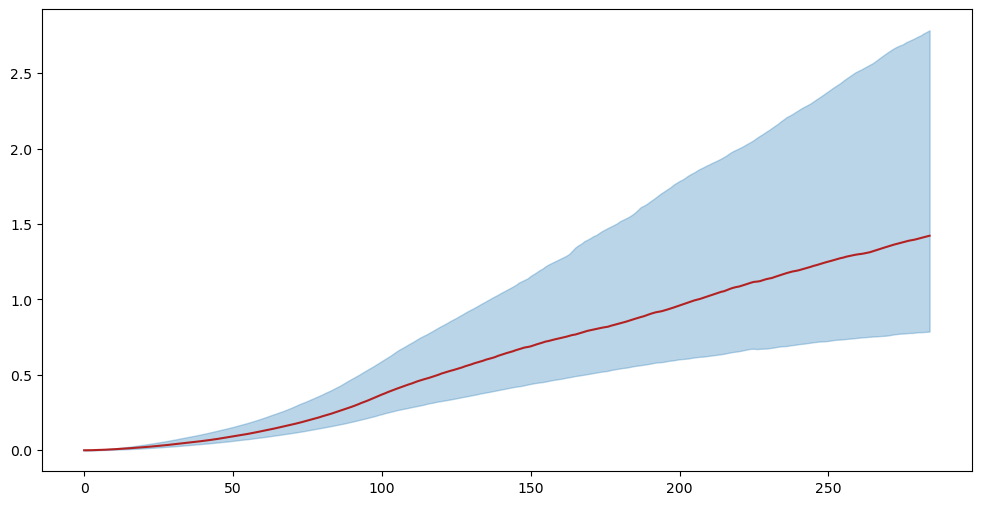

In [43]:
# Eval plot
fig = plt.figure(figsize=(12, 6))
lower = np.percentile(ais_preds, 17, axis=(0))
upper = np.percentile(ais_preds, 83, axis=(0))
plt.fill_between(np.arange(len(lower)), lower, upper, color='C0', alpha=0.3, label='17-83% Confidence')
med = np.median(ais_preds, axis=(0))
plt.plot(med, color="firebrick")

plt.show()

Running idealised predictions...


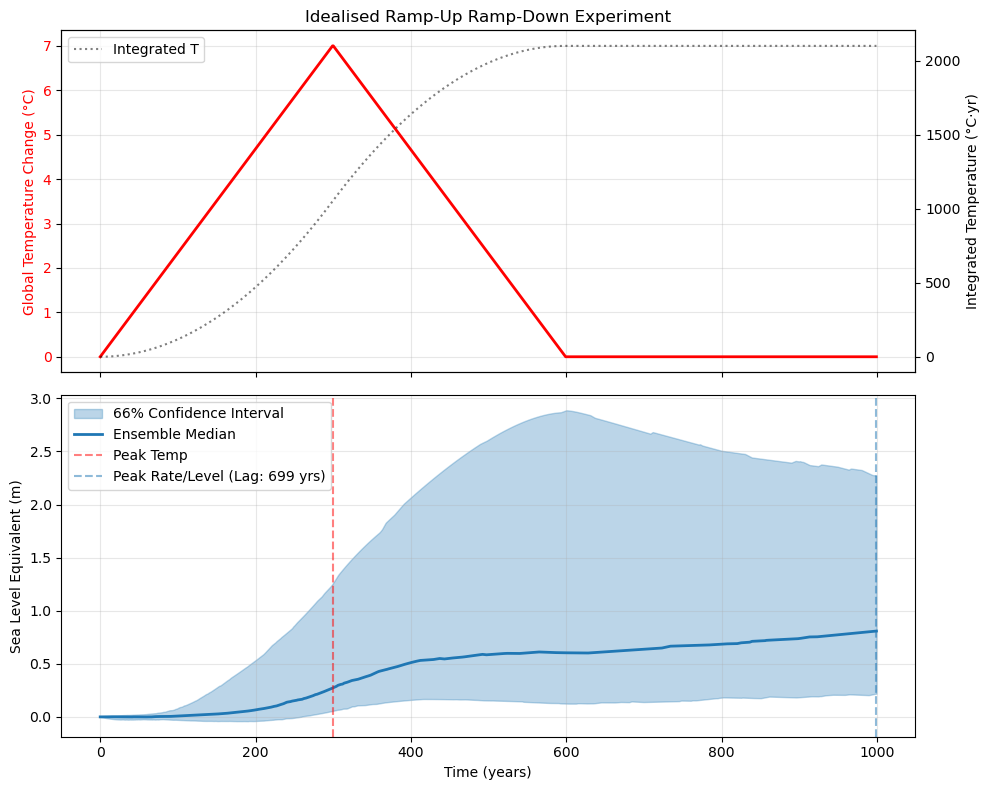

In [ ]:
# --- 1. Helper Functions (copied for self-containment) ---

def f_poly_mixed(tas, t_int, params_gen, params_perturb):
    # params: [alpha, beta, gamma]
    p = params_gen + params_perturb
    return (p[:, 0, None] * tas) + (p[:, 2, None] * t_int)

def impulse_response_fitter(f_inst_vals, tau, dt=1):
    n = len(f_inst_vals)
    tau = max(tau, 1e-3)
    decay_factors = np.exp(-np.arange(n) * dt / tau) * (dt / tau)
    response = np.zeros(n)
    for k in range(n):
        response[k] = np.sum(decay_factors[:k+1] * f_inst_vals[k::-1])
    return response

def predict_ais_me_poly(X, general_params, general_taus, mv_dists):
    tas, t_int = X
    n_models = len(general_params)
    n_samples = mv_dists[0].shape[0]
    n_time = len(tas)
    all_preds = np.zeros((n_models, n_samples, n_time))
    
    for m in range(n_models):
        tau = general_taus[m]
        gen_p = general_params[m]
        perturb_p = mv_dists[m]
        
        f_vals = f_poly_mixed(tas[None, :], t_int[None, :], gen_p[None, :], perturb_p)
        
        for i in range(n_samples):
            all_preds[m, i, :] = impulse_response_fitter(f_vals[i], tau, dt=1)
            
    return all_preds

# --- 2. Construct Idealised Forcing ---

n_years = 1000
peak_temp = 7.0  # Degrees warming
ramp_len = 300    # Years to ramp up/down

# Create time axis
time = np.arange(n_years)
tas_ideal = np.zeros(n_years)

# Ramp Up (0 to 50 years)
tas_ideal[:ramp_len] = np.linspace(0, peak_temp, ramp_len)

# Ramp Down (50 to 100 years)
tas_ideal[ramp_len:ramp_len*2] = np.linspace(peak_temp, 0, ramp_len)
tas_ideal[ramp_len*2:] = 0

# Stabilization (100+ years) -> Remains at 0
# Note: In reality, physics might suggest T approaches equilibrium, but 0 is good for testing.

# Integrate Temperature
# We assume dt=1 year
t_int_ideal = np.cumsum(tas_ideal)

# --- 3. Run Prediction ---



print("Running idealised predictions...")
# wa_pred = wa_ais.predict(tas_ideal, t_int_ideal)
# ea_pred = ea_ais.predict(tas_ideal, t_int_ideal)
# pen_pred = pen_ais.predict(tas_ideal, t_int_ideal)
# preds = wa_pred + ea_pred

preds = predict_split_ensemble_empirical_additive((tas_ideal, t_int_ideal), general_params, general_timescales, general_gammas, param_residuals)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot Forcing
ax1.plot(time, tas_ideal, 'r-', lw=2, label='Temperature (TAS)')
ax1.set_ylabel("Global Temperature Change (°C)", color='r')
ax1.tick_params(axis='y', labelcolor='r')
ax1.set_title("Idealised Ramp-Up Ramp-Down Experiment")
ax1.grid(True, alpha=0.3)

# Add Integrated T to secondary axis to show why melt continues
ax1b = ax1.twinx()
ax1b.plot(time, t_int_ideal, 'k:', alpha=0.5, label='Integrated T')
ax1b.set_ylabel("Integrated Temperature (°C·yr)", color='k')
ax1b.legend(loc='upper left')

# Plot Response (Aggregate of all models if multiple exist)
# Flatten all models/samples to get the grand ensemble stats
flat_preds = preds.reshape(-1, preds.shape[-1])
p5 = np.percentile(flat_preds, 17, axis=0)
p50 = np.median(flat_preds, axis=0)
p95 = np.percentile(flat_preds, 83, axis=0)

ax2.fill_between(time, p5, p95, color='C0', alpha=0.3, label='66% Confidence Interval')
ax2.plot(time, p50, color='C0', lw=2, label='Ensemble Median')

# Highlight the "Peak Melt" vs "Peak Temp" lag
peak_melt_idx = np.argmax(p50)
lag_years = time[peak_melt_idx] - ramp_len
ax2.axvline(x=ramp_len, color='r', linestyle='--', alpha=0.5, label='Peak Temp')
ax2.axvline(x=time[peak_melt_idx], color='C0', linestyle='--', alpha=0.5, label=f'Peak Rate/Level (Lag: {lag_years} yrs)')

ax2.set_xlabel("Time (years)")
ax2.set_ylabel("Sea Level Equivalent (m)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

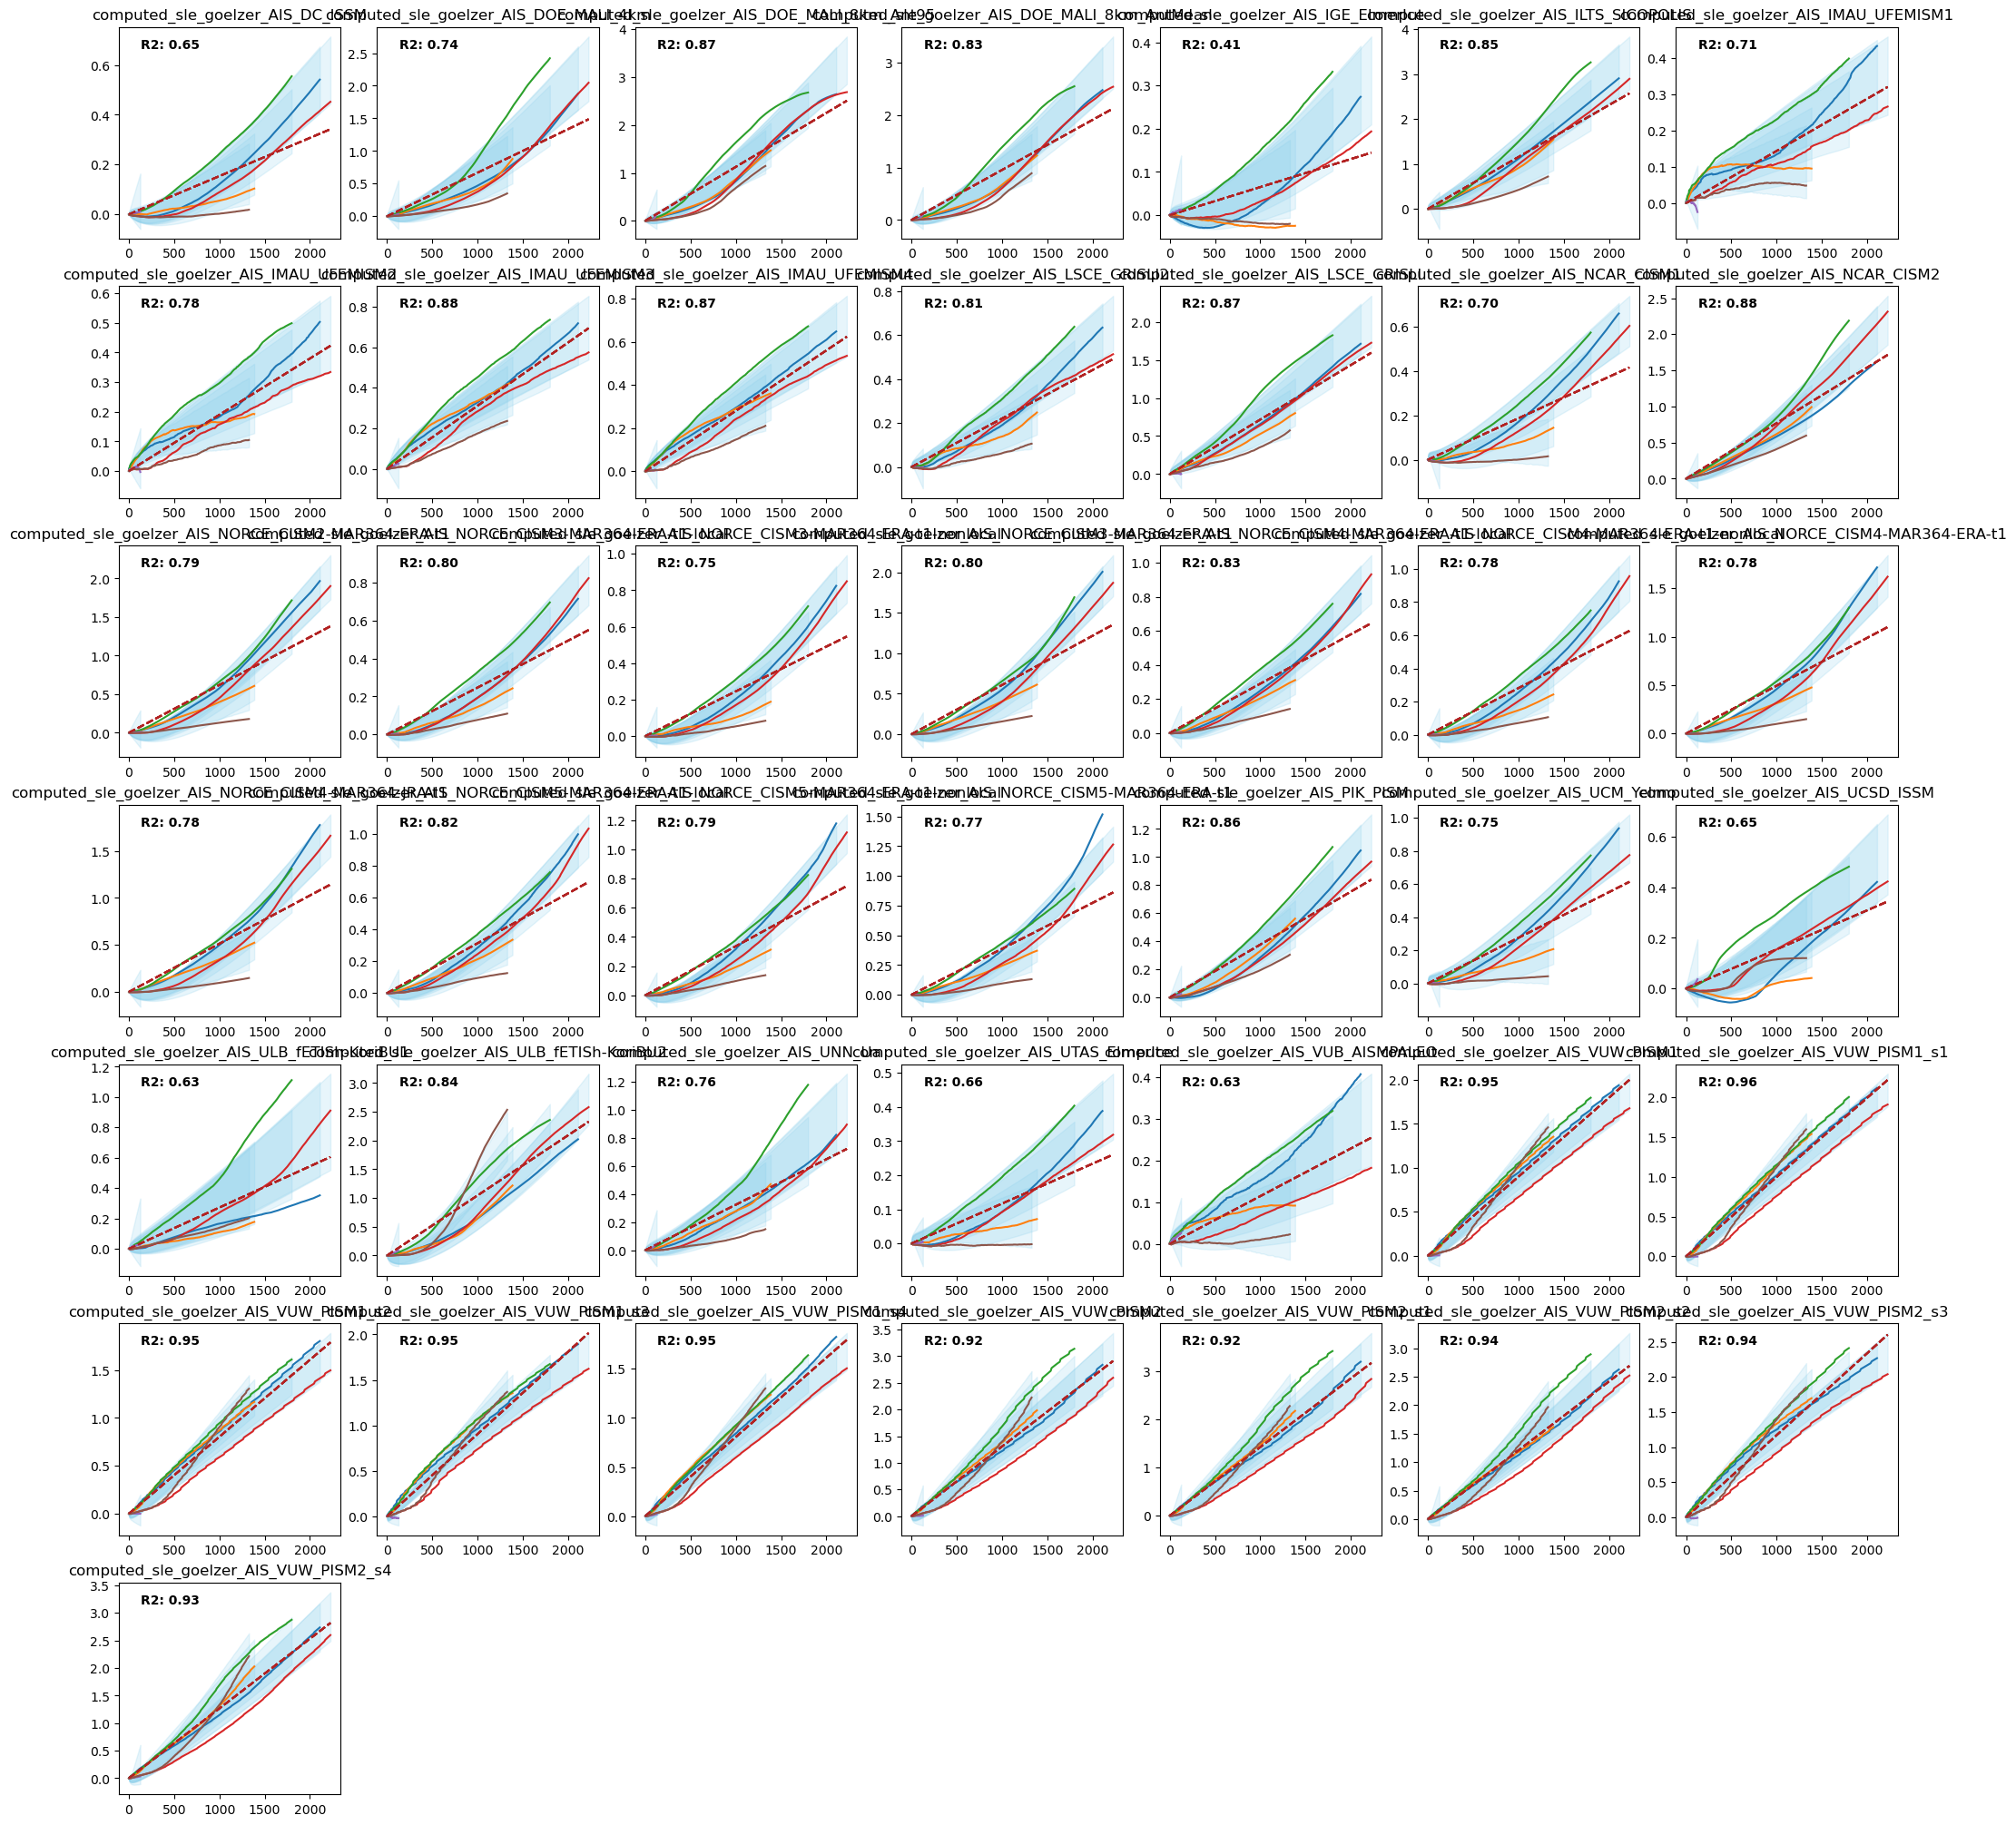

[2, 8, 9, 11, 13, 25, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42]


In [ ]:
from sklearn.linear_model import LinearRegression
regr = LinearRegression(fit_intercept=False)

fig = plt.figure(figsize=(20, 20), layout="constrained")

consistent_idx = []
for m in range(sle_train.shape[1]):
    ax = fig.add_subplot(7, 7, m + 1)
    ax.set_title(f"{model_names[m]}")
    time = np.arange(len(t_int_train[0]))
    t_int_xgrid = np.linspace(np.min(t_int_train), np.max(t_int_train), 1000)
    t_int_r = regr.fit(t_int_train.reshape(-1, 1), sle_train[:, m].reshape(-1, 1))
    t_int_r2 = t_int_r.score(t_int_train.reshape(-1, 1), sle_train[:, m].reshape(-1, 1))
    t_int_y = np.squeeze(t_int_r.coef_ * t_int_xgrid)

    if t_int_r2 >= 0.85:
        consistent_idx.append(m)

    for scen in range(6):
        preds = predict_split_ensemble_empirical_additive(
            (tas_train[scen], t_int_train[scen]), 
            general_params, 
            general_timescales, 
            general_gammas, 
            param_residuals,
            n_samples=1000
        )[m]
        p5 = np.percentile(preds, 0, axis=0)
        p95 = np.percentile(preds, 100, axis=0)
        
        ax.plot(t_int_train[scen], sle_train[scen, m])
        ax.plot(t_int_xgrid, t_int_y, ls="--", color="firebrick")
        ax.fill_between(t_int_train[scen], p5, p95, color='skyblue', alpha=0.2, label='5-95% Confidence')

    ax.text(0.1, 0.9, f"R2: {t_int_r2:.2f}", transform=ax.transAxes, fontweight="bold")
plt.show()

print(consistent_idx)